In [ ]:
!pip install pandas matplotlib gdown

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import gdown
import os

In [3]:
# Download data from Google Sheets using gdown
sheet_id = '1e_lKct9ovnYByYkGpFCKrMpKQs5TQdKhTld9tDU1JcQ'
sheet_gid = '1499552579' 
results_data = f'https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={sheet_gid}'

csv_file = 'results_data.csv'

gdown.download(results_data, csv_file, quiet=False)

/home/diogoocv/miniconda3/envs/SMAC/lib/python3.10/site-packages/gdown/parse_url.py:48: UserWarning: You specified a Google Drive link that is not the correct link to download a file. You might want to try `--fuzzy` option or the following url: https://drive.google.com/uc?id=None
  warnings.warn(
Downloading...
From: https://docs.google.com/spreadsheets/d/1e_lKct9ovnYByYkGpFCKrMpKQs5TQdKhTld9tDU1JcQ/export?format=csv&gid=1499552579
To: /home/diogoocv/IdeaProjects/fractal/plots/CCPE_Plots/results_data.csv
53.2kB [00:00, 2.01MB/s]


'results_data.csv'

In [4]:
# Load dataset
df = pd.read_csv(csv_file)
df

,metaheuristic,graph,obj_function,threads,init_solutions,timeout_ms,AVERAGE of cost,STDEV of cost,COUNT of cost,budget_ms,ci_cost,avg_cost_baseline,threads_baseline,normalized_cost,normalized_threads,normalized_ci
0,ils,amazon,conductance,15,33,2781,0.787200,0.037324,5,9375,0.046343,0.983248,32,0.800612,0.46875,0.047133
1,ils,amazon,conductance,21,83,1115,0.955466,0.008314,5,6250,0.010323,0.984615,32,0.970395,0.65625,0.010484
2,ils,amazon,conductance,32,100,1000,0.984615,0.000000,5,3125,0.000000,0.984615,32,1.000000,1.00000,0.000000
3,ils,amazon,conductance,32,785,2543,0.993333,0.000000,5,93750,0.000000,0.993333,32,1.000000,1.00000,0.000000
4,ils,amazon,conductance,32,1000,1000,0.993333,0.000000,5,31250,0.000000,0.993333,32,1.000000,1.00000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
427,vns,youtube,triangledensestsubgraph,18,40,7388,186.481835,18.222679,5,31250,22.626444,300.690369,32,0.620179,0.56250,0.075248
428,vns,youtube,triangledensestsubgraph,23,54,1187,178.944444,8.540537,5,3125,10.604478,184.492677,32,0.969927,0.71875,0.057479
429,vns,youtube,triangledensestsubgraph,25,83,1542,180.517677,11.177422,5,6250,13.878602,191.026263,32,0.944989,0.78125,0.072653
430,vns,youtube,triangledensestsubgraph,25,332,2747,248.117647,0.000000,5,62500,0.000000,287.188499,32,0.863954,0.78125,0.000000


In [5]:
# Clean up column names
df.columns = df.columns.astype(str).str.strip().str.lower().str.replace(' ', '_')
df['metaheuristic'] = df['metaheuristic'].replace({'ts1': 'ts'})
df

,metaheuristic,graph,obj_function,threads,init_solutions,timeout_ms,average_of_cost,stdev_of_cost,count_of_cost,budget_ms,ci_cost,avg_cost_baseline,threads_baseline,normalized_cost,normalized_threads,normalized_ci
0,ils,amazon,conductance,15,33,2781,0.787200,0.037324,5,9375,0.046343,0.983248,32,0.800612,0.46875,0.047133
1,ils,amazon,conductance,21,83,1115,0.955466,0.008314,5,6250,0.010323,0.984615,32,0.970395,0.65625,0.010484
2,ils,amazon,conductance,32,100,1000,0.984615,0.000000,5,3125,0.000000,0.984615,32,1.000000,1.00000,0.000000
3,ils,amazon,conductance,32,785,2543,0.993333,0.000000,5,93750,0.000000,0.993333,32,1.000000,1.00000,0.000000
4,ils,amazon,conductance,32,1000,1000,0.993333,0.000000,5,31250,0.000000,0.993333,32,1.000000,1.00000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
427,vns,youtube,triangledensestsubgraph,18,40,7388,186.481835,18.222679,5,31250,22.626444,300.690369,32,0.620179,0.56250,0.075248
428,vns,youtube,triangledensestsubgraph,23,54,1187,178.944444,8.540537,5,3125,10.604478,184.492677,32,0.969927,0.71875,0.057479
429,vns,youtube,triangledensestsubgraph,25,83,1542,180.517677,11.177422,5,6250,13.878602,191.026263,32,0.944989,0.78125,0.072653
430,vns,youtube,triangledensestsubgraph,25,332,2747,248.117647,0.000000,5,62500,0.000000,287.188499,32,0.863954,0.78125,0.000000


In [6]:
# Define standard styling 
metaheuristics = df['metaheuristic'].unique()
colors = {'vns': '#1f77b4', 'ils': '#ff7f0e', 'ts': '#2ca02c'}

# Map unique budgets to specific markers
unique_budgets = sorted(df['budget_ms'].dropna().unique())
available_markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'h', 'X'] 
budget_markers = {budget: available_markers[i % len(available_markers)] for i, budget in enumerate(unique_budgets)}

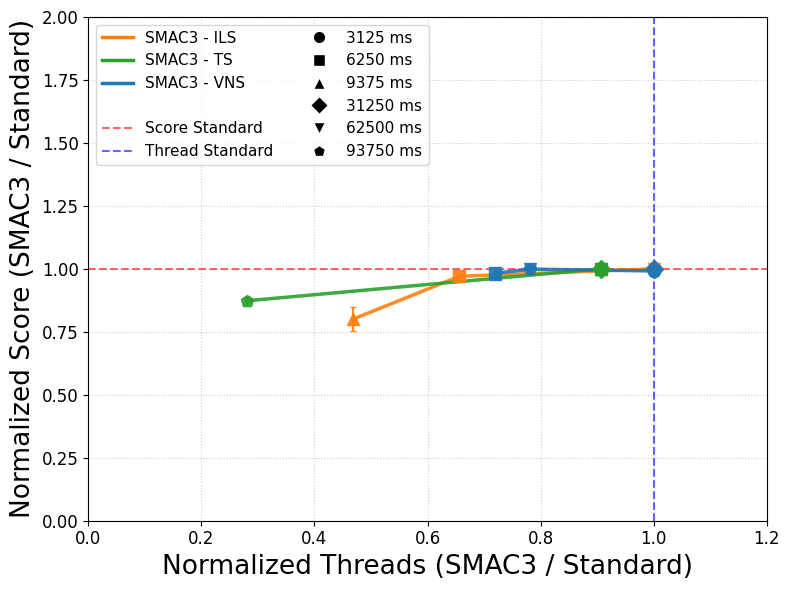

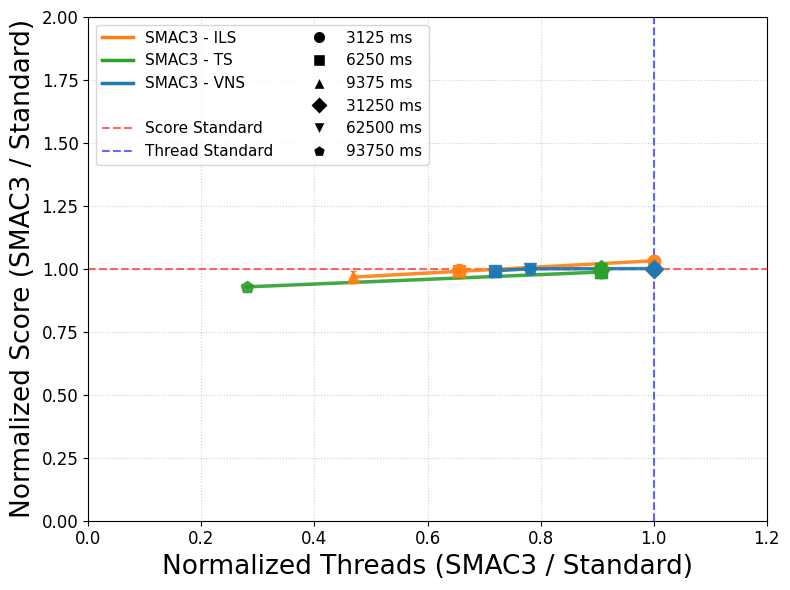

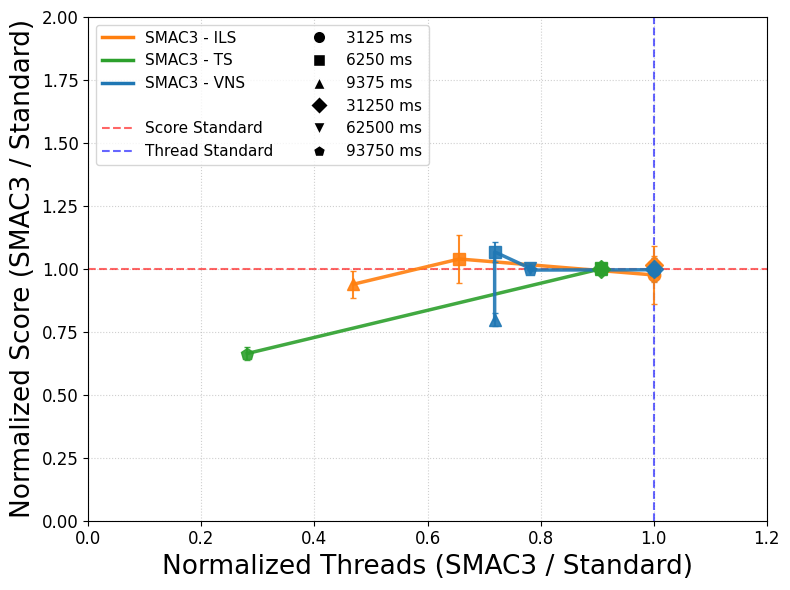

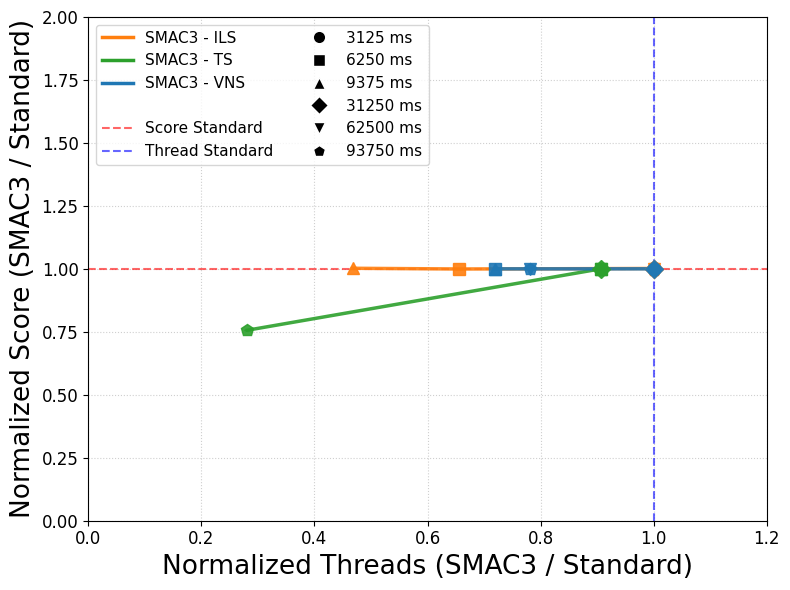

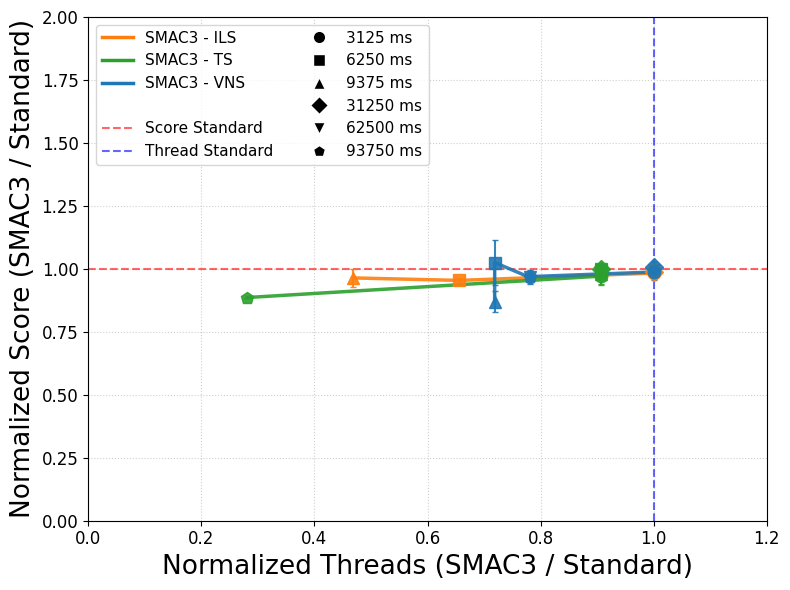

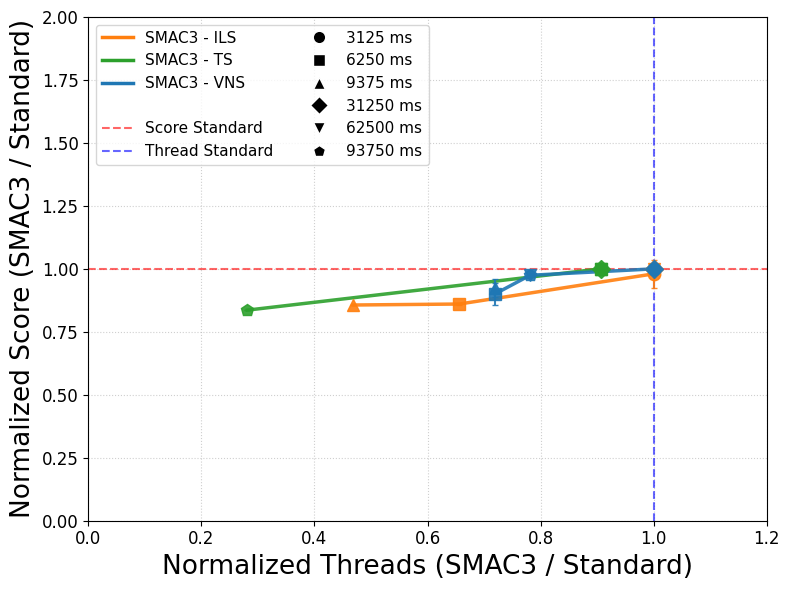

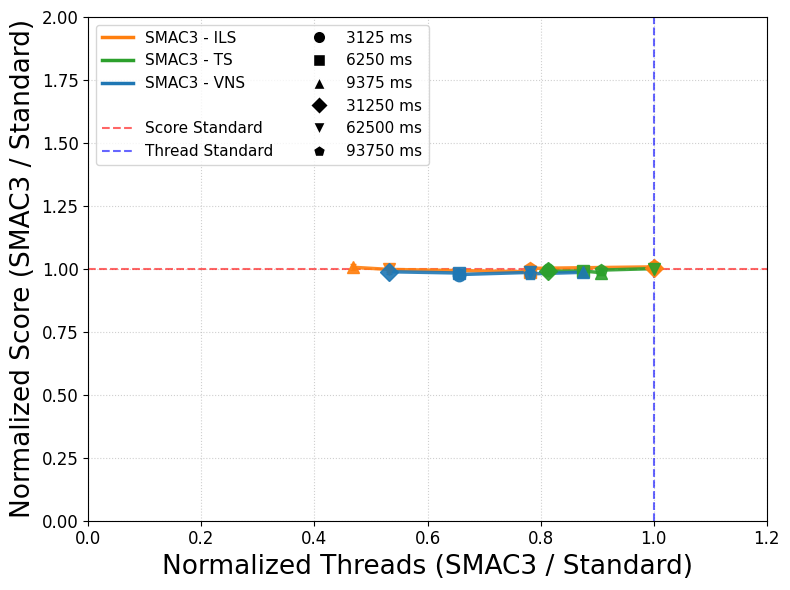

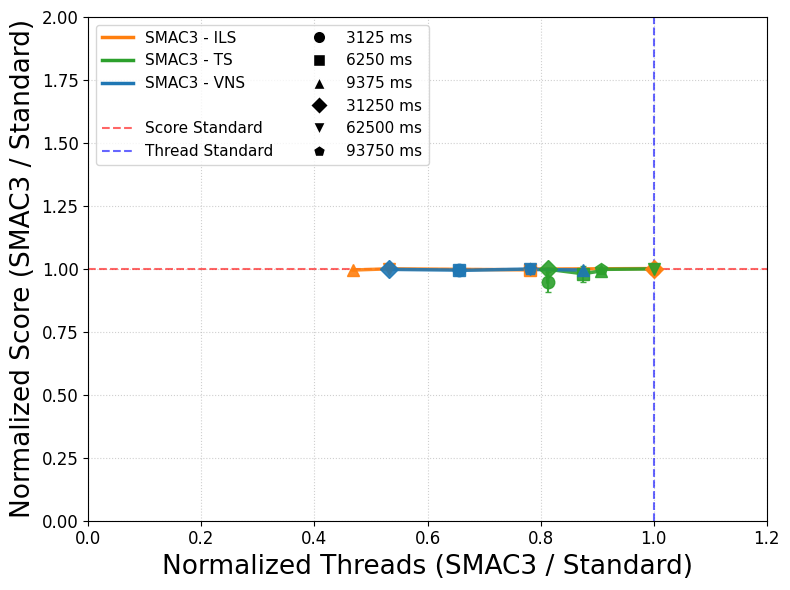

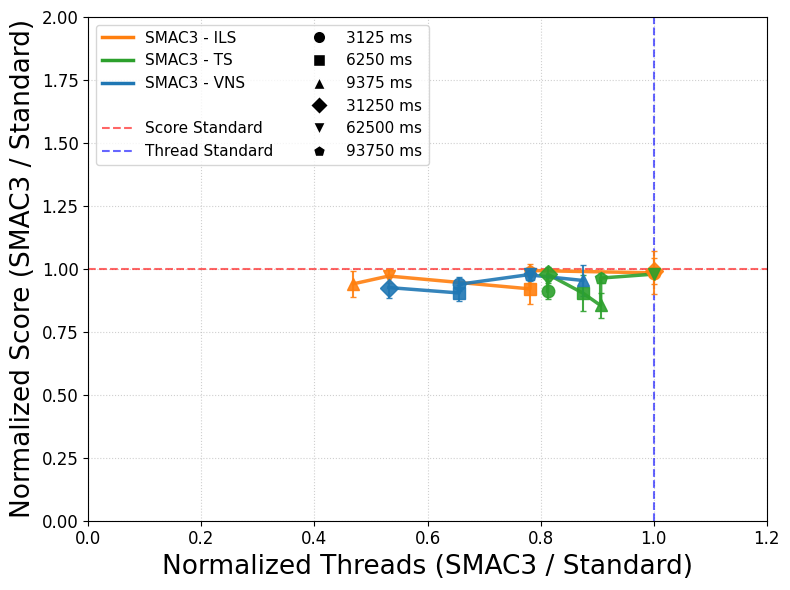

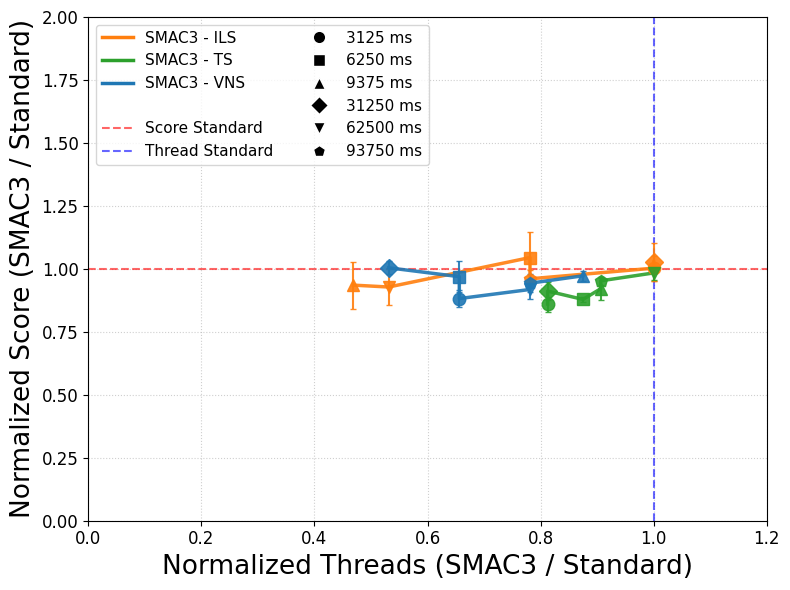

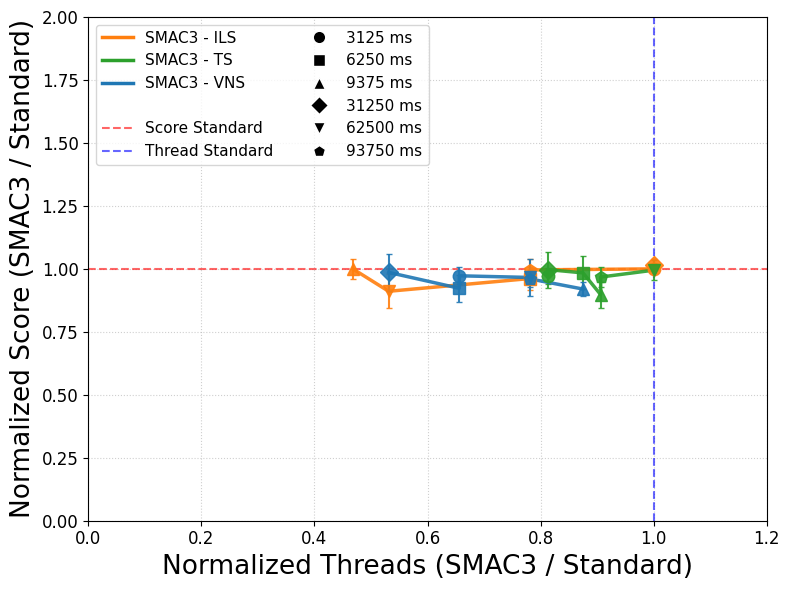

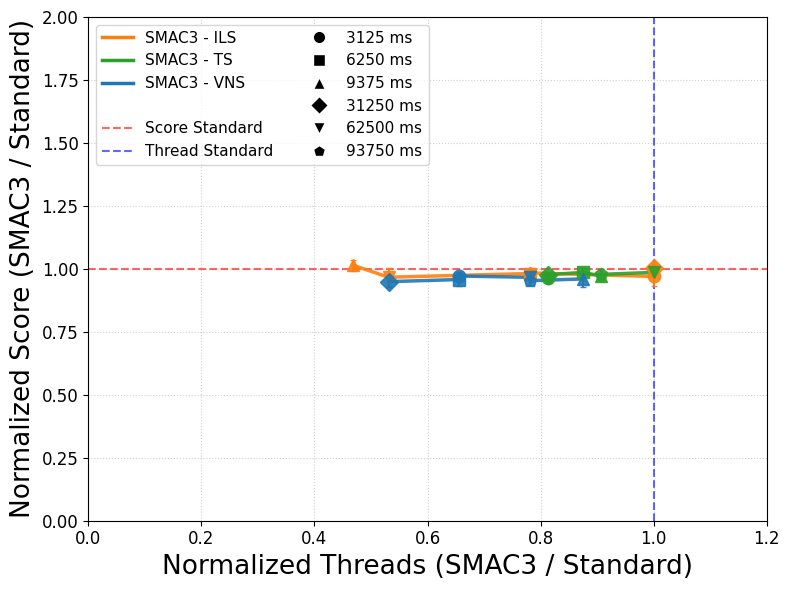

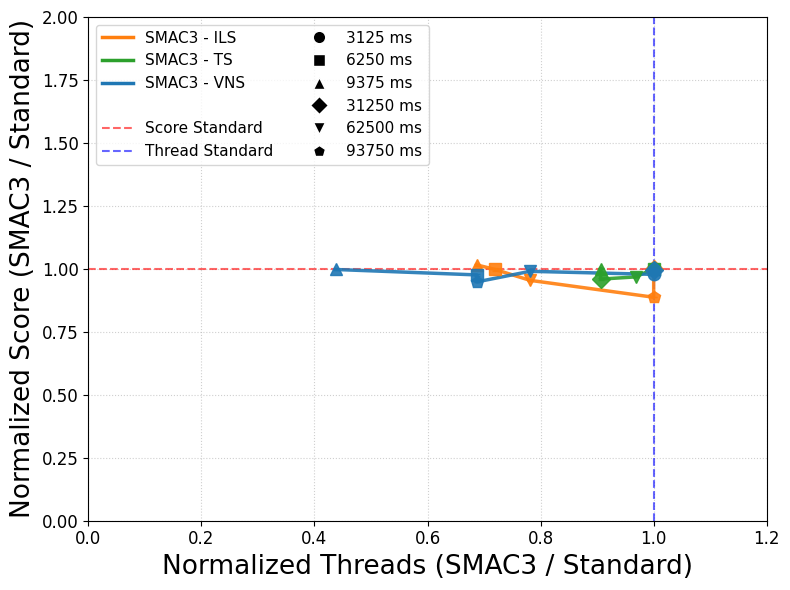

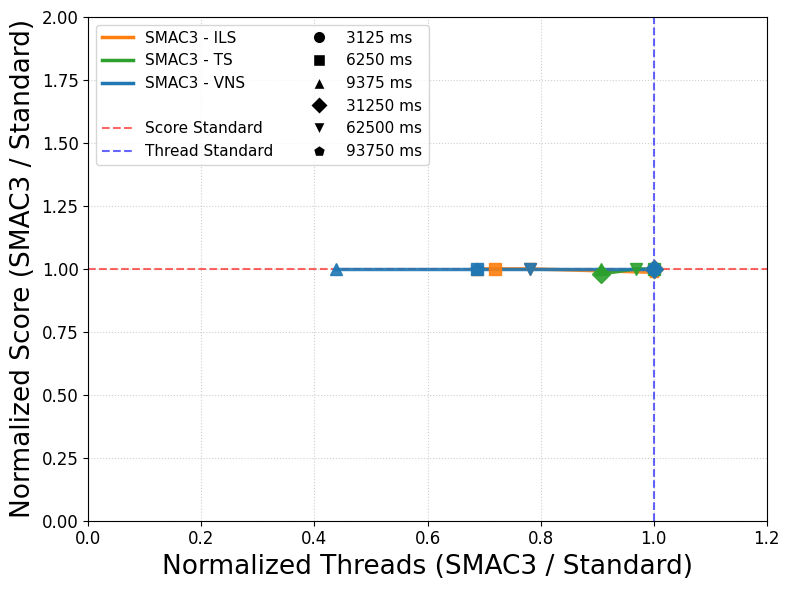

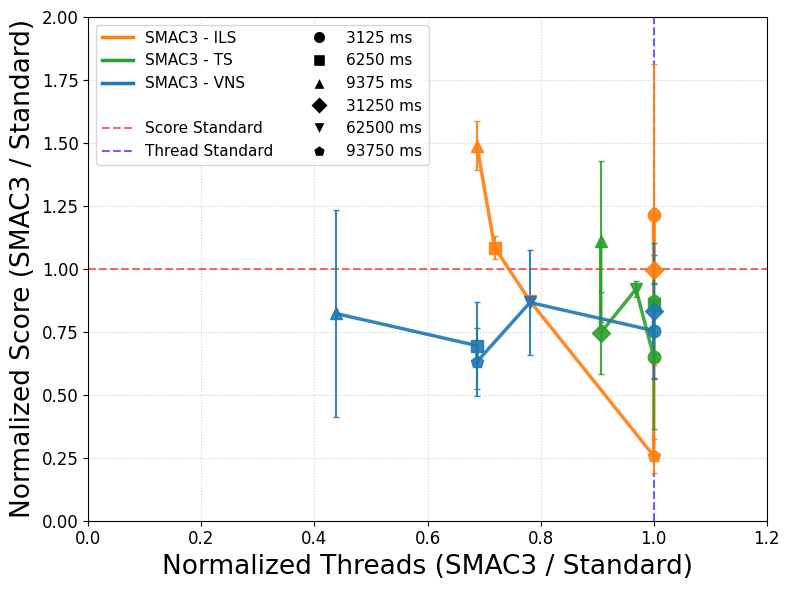

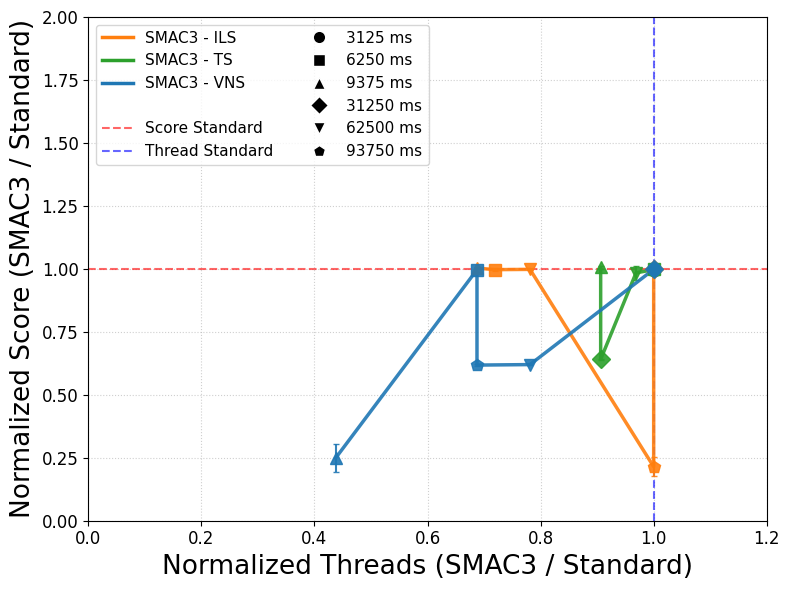

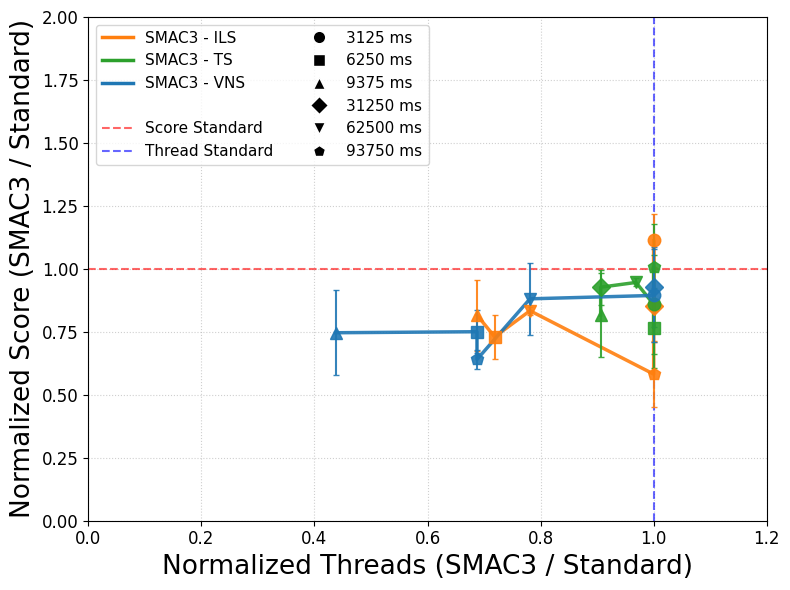

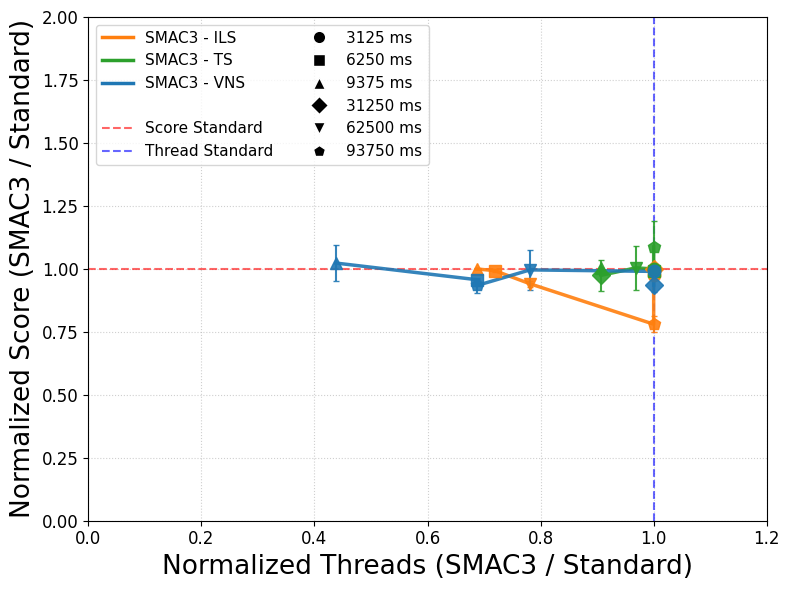

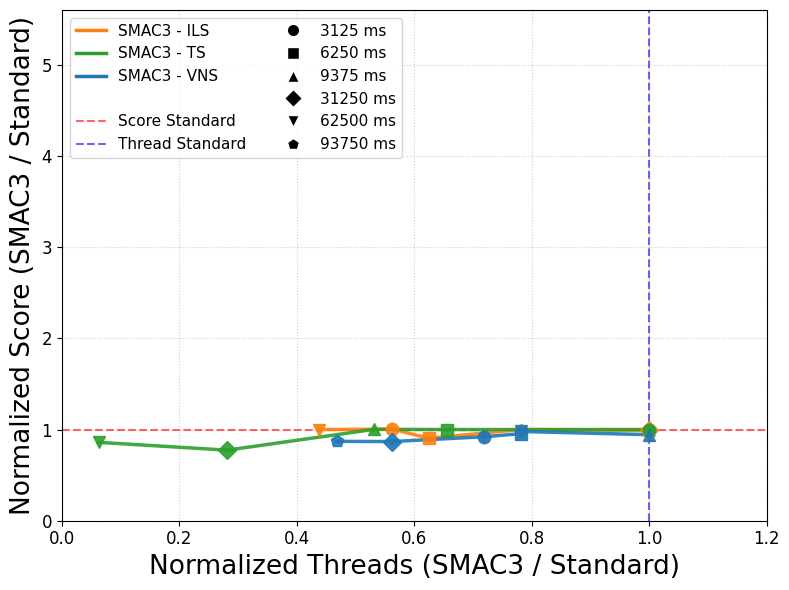

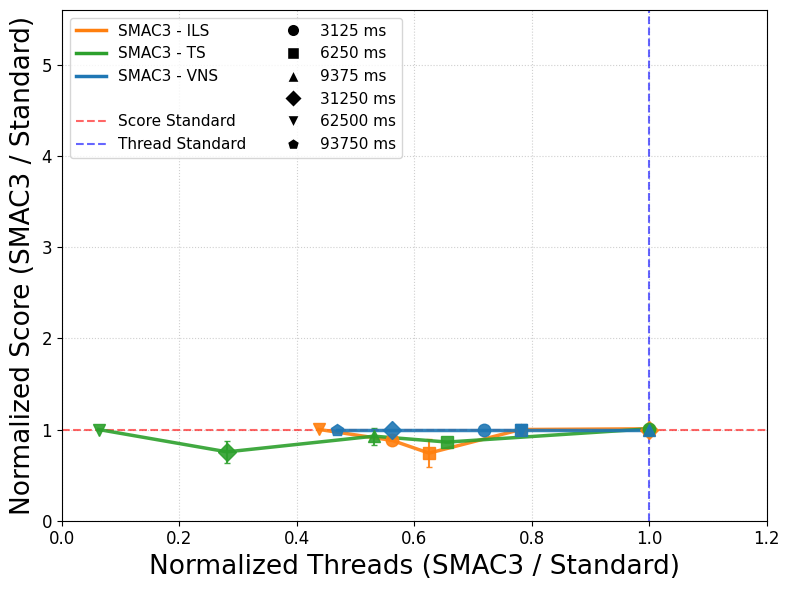

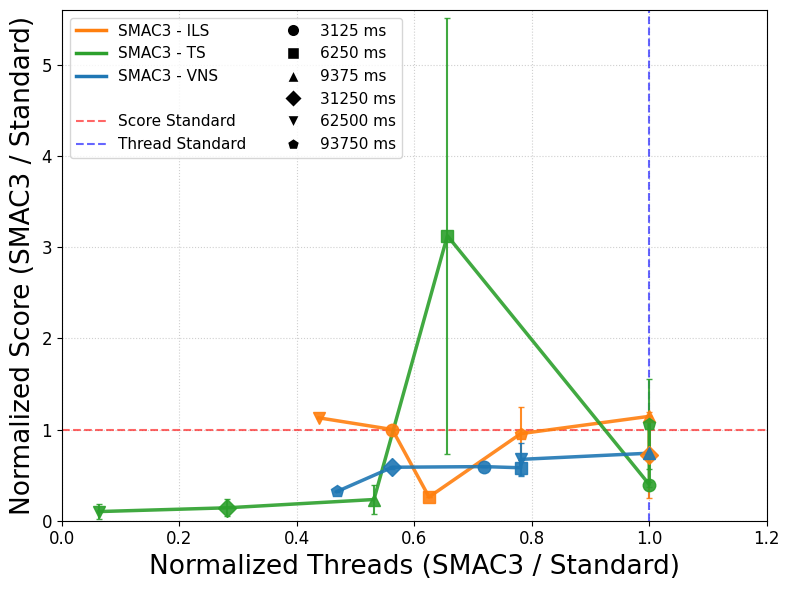

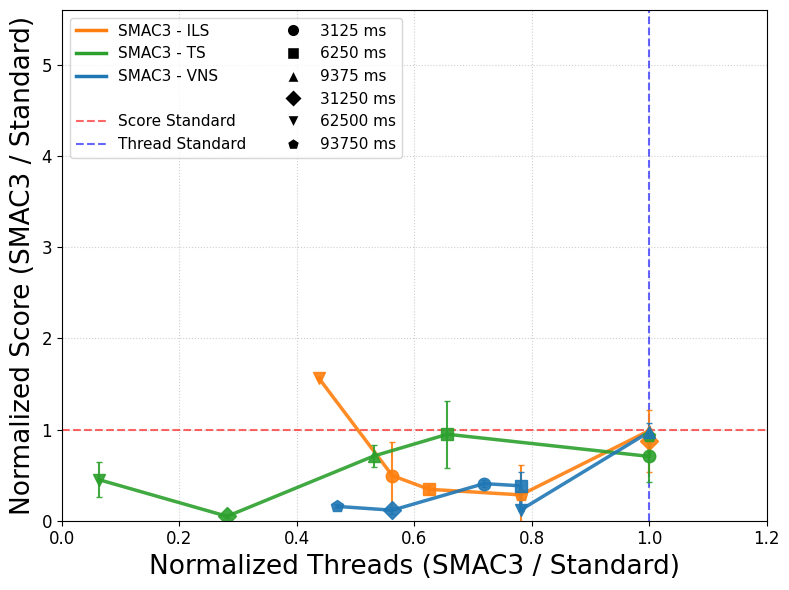

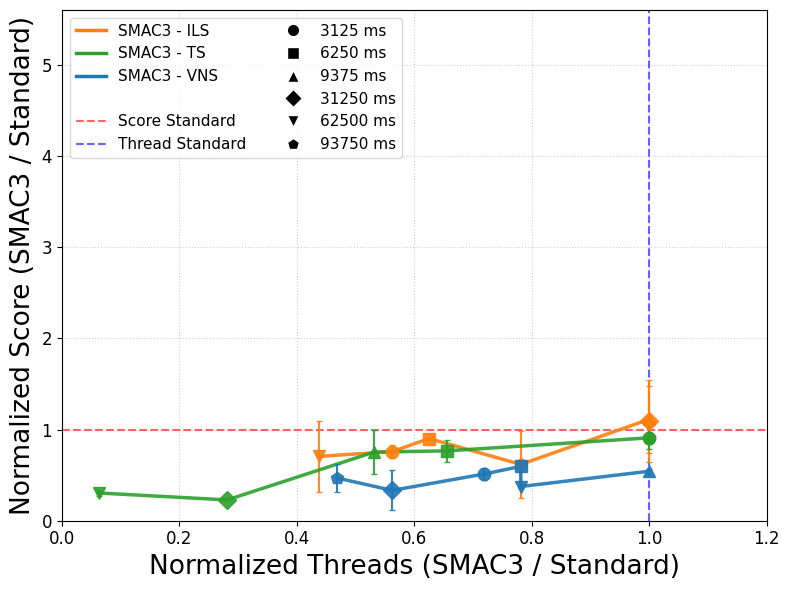

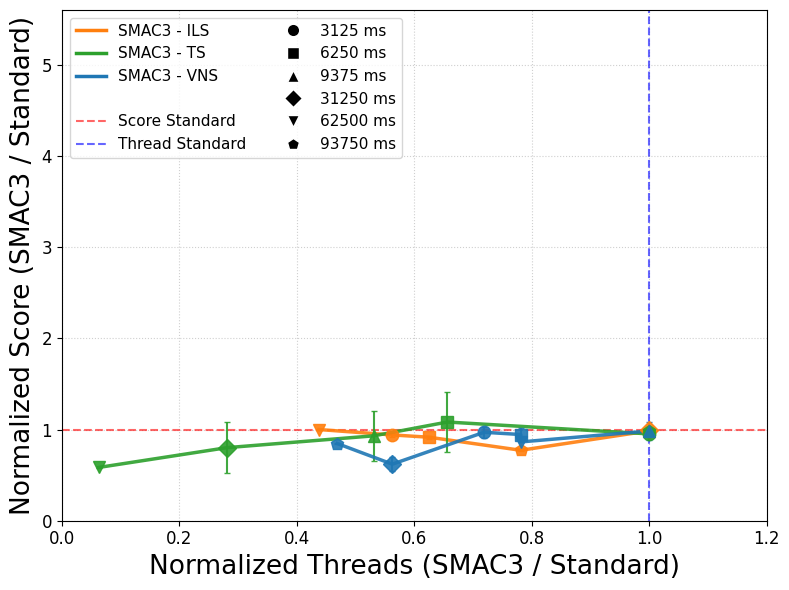

In [8]:
# Generate the plots
objectives = df['obj_function'].unique()
graphs = df['graph'].unique()

for obj_func in objectives:
    for graph in graphs:
        
        plot_data = df[(df['obj_function'] == obj_func) & (df['graph'] == graph)].copy()
        if plot_data.empty:
            continue
        
        plot_data.sort_values(by=['metaheuristic', 'normalized_threads'], inplace=True)

        fig, ax = plt.subplots(figsize=(8, 6))
        
        ax.set_xlabel('Normalized Threads (SMAC3 / Standard)', fontsize=19)
        ax.set_ylabel('Normalized Score (SMAC3 / Standard)', fontsize=19)
        ax.tick_params(axis='both', which='major', labelsize=12)
        ax.set_xlim(0, 1.2)

        if(obj_func == "triangledensestsubgraph"):
            ax.set_ylim(0, 5.6)
        else:
            ax.set_ylim(0, 2)
        
        ax.axhline(1.0, color='red', linestyle='--', alpha=0.6, label='Score Standard')
        ax.axvline(1.0, color='blue', linestyle='--', alpha=0.6, label='Thread Standard')
        
        # Plot each metaheuristic 
        for meta in metaheuristics:
            meta_data = plot_data[plot_data['metaheuristic'] == meta]
            
            if not meta_data.empty:
                # Draw the continuous line for the Metaheuristic
                ax.plot(
                    meta_data['normalized_threads'],
                    meta_data['normalized_cost'],
                    color=colors.get(meta, 'black'),
                    linestyle='-',
                    linewidth=2.5,
                    alpha=0.9
                )
                
                # Loop through budgets and stamp the specific markers + error bars
                for budget in unique_budgets:
                    budget_data = meta_data[meta_data['budget_ms'] == budget]
                    
                    if not budget_data.empty:
                        ax.errorbar(
                            budget_data['normalized_threads'],
                            budget_data['normalized_cost'],
                            yerr=budget_data['normalized_ci'],
                            color=colors.get(meta, 'black'),
                            marker=budget_markers[budget],
                            markersize=9,         # Slightly larger to make shapes clear
                            linestyle='none',     # NO LINE here, just the stamp
                            elinewidth=1.5,
                            capsize=2,
                            alpha=0.9
                        )
        
        ax.grid(True, which="major", ls=":", alpha=0.6)
        
        # Build a custom legend
        legend_elements = []
        for meta in metaheuristics:
            legend_elements.append(mlines.Line2D([0], [0], color=colors[meta], lw=2.5, label=f"SMAC3 - {meta.upper()}"))
            
        # Add a blank spacer
        legend_elements.append(mlines.Line2D([], [], color='none', label=' '))

        # Manually add the baselines
        legend_elements.append(mlines.Line2D([0], [0], color='red', linestyle='--', alpha=0.6, label='Score Standard'))
        legend_elements.append(mlines.Line2D([0], [0], color='blue', linestyle='--', alpha=0.6, label='Thread Standard'))
        
        
        # Add budgets to legend
        for budget in unique_budgets:
            b_int = int(budget)
            b_label = f"{b_int} ms"
            legend_elements.append(mlines.Line2D([0], [0], marker=budget_markers[budget], color='w',
                                                 markerfacecolor='black', markersize=9, label=f"{b_label}"))
            
        
        # Apply the custom legend
        ax.legend(handles=legend_elements, loc='best', fontsize=11, ncol=2)
        
        plt.tight_layout()

        # Save file
        output_folder = "pareto_plots/quality_threads"
        os.makedirs(output_folder, exist_ok=True)
        filename = f'quality_threads_{graph}_{obj_func}.pdf'
        filepath = os.path.join(output_folder, filename)
        plt.savefig(filepath, bbox_inches='tight')
        
        plt.show()